In [15]:
import joblib
from pprint import pprint
from pathlib import Path

In [16]:
!pip install --upgrade scikit-learn==1.8.0

In [17]:
path =Path("/home/crisr_cvail/CCC-ML-Project/tabtext/experiments/manual_models_tabular_plus_clinical_longformer_valid_f1_20260709_102931/models/catboost.joblib")

In [18]:
artifact = joblib.load(path)

print("CLAVES:")
print(artifact.keys())

print("\nTHRESHOLD:")
print(artifact["selected_threshold_on_valid"])

print("\nRESULT:")
pprint(artifact["result"])

CLAVES:
dict_keys(['preprocessor', 'model', 'selected_threshold_on_valid', 'result'])

THRESHOLD:
0.51

RESULT:
{'best_params': {'depth': 3,
                 'iterations': 100,
                 'l2_leaf_reg': 0.009109000828121083,
                 'learning_rate': 0.005492901312497813,
                 'random_strength': 0.6443861078749499},
 'best_valid_f1_from_optuna': 0.6666666666666666,
 'model': 'catboost',
 'objective': 'maximize_valid_f1_on_holdout',
 'selected_threshold_on_valid': 0.51,
 'test': {'accuracy': 0.8271604938271605,
          'f1_score': 0.7083333333333334,
          'fn': 4,
          'fp': 10,
          'pr_auc': 0.6870131504530002,
          'precision': 0.6296296296296297,
          'recall_sensitivity': 0.8095238095238095,
          'roc_auc': 0.8746031746031746,
          'specificity': 0.8333333333333194,
          'threshold': 0.51,
          'tn': 50,
          'tp': 17},
 'threshold_strategy': 'single_threshold_maximizing_f1_on_validation_predictions',
 'v

In [19]:
artifact = joblib.load(path)

print("=" * 80)
print("CLAVES DEL ARTIFACT")
print("=" * 80)
print(artifact.keys())

print("\n" + "=" * 80)
print("THRESHOLD")
print("=" * 80)
print(artifact["selected_threshold_on_valid"])

print("\n" + "=" * 80)
print("TIPO DE PREPROCESSOR")
print("=" * 80)
print(type(artifact["preprocessor"]))

print("\n" + "=" * 80)
print("PREPROCESSOR")
print("=" * 80)
print(artifact["preprocessor"])

print("\n" + "=" * 80)
print("TIPO DE MODELO")
print("=" * 80)
print(type(artifact["model"]))

print("\n" + "=" * 80)
print("MODELO")
print("=" * 80)
print(artifact["model"])

print("\n" + "=" * 80)
print("TIPO DE RESULT")
print("=" * 80)
print(type(artifact["result"]))

print("\n" + "=" * 80)
print("RESULT")
print("=" * 80)
pprint(artifact["result"])

if isinstance(artifact["result"], dict):
    print("\n" + "=" * 80)
    print("CLAVES DE RESULT")
    print("=" * 80)
    print(artifact["result"].keys())

CLAVES DEL ARTIFACT
dict_keys(['preprocessor', 'model', 'selected_threshold_on_valid', 'result'])

THRESHOLD
0.51

TIPO DE PREPROCESSOR
<class 'sklearn.compose._column_transformer.ColumnTransformer'>

PREPROCESSOR
ColumnTransformer(sparse_threshold=0.0,
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Sexo', 'Edad al ingreso',
                                  'Área de residencia', 'Frecuencia cardiaca',
                                  'Presión diastólica cardíaca',
                                  'Presión sistólica cardíaca', 'Peso', 'Talla',
                                  'IMC', 'FEVI', 'Antecedente de arritmia',
                                  'Antecedente de hipertensión ar...
                                  'Antecedente d

In [20]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Ajusta esta ruta si tu notebook está en otra ubicación
PROJECT_ROOT = Path.cwd()

MODEL_PATH = Path("/home/crisr_cvail/CCC-ML-Project/tabtext/experiments/manual_models_tabular_plus_clinical_longformer_valid_f1_20260709_102931/models/catboost.joblib")
TEST_PATH = Path("/home/crisr_cvail/CCC-ML-Project/tabtext/outputs_test_pca_all_english/tabular_longformer/tabular_longformer_test.csv")

TARGET_COL = "desenlace_combinado"

print("Modelo:", MODEL_PATH)
print("Test:", TEST_PATH)

Modelo: /home/crisr_cvail/CCC-ML-Project/tabtext/experiments/manual_models_tabular_plus_clinical_longformer_valid_f1_20260709_102931/models/catboost.joblib
Test: /home/crisr_cvail/CCC-ML-Project/tabtext/outputs_test_pca_all_english/tabular_longformer/tabular_longformer_test.csv


In [21]:
artifact = joblib.load(MODEL_PATH)

preprocessor = artifact["preprocessor"]
model = artifact["model"]
threshold = artifact["selected_threshold_on_valid"]

print("Modelo:", type(model))
print("Preprocessor:", type(preprocessor))
print("Threshold:", threshold)

Modelo: <class 'catboost.core.CatBoostClassifier'>
Preprocessor: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Threshold: 0.51


In [22]:
df_test = pd.read_csv(TEST_PATH)

print("Dimensiones:", df_test.shape)
print("Columnas:", len(df_test.columns))

df_test.head()

Dimensiones: (81, 840)
Columnas: 840


,Sexo,Edad al ingreso,Área de residencia,Frecuencia cardiaca,Presión diastólica cardíaca,Presión sistólica cardíaca,Peso,Talla,IMC,FEVI,...,clinical_longformer_emb_759,clinical_longformer_emb_760,clinical_longformer_emb_761,clinical_longformer_emb_762,clinical_longformer_emb_763,clinical_longformer_emb_764,clinical_longformer_emb_765,clinical_longformer_emb_766,clinical_longformer_emb_767,desenlace_combinado
0,0,84.296661,1,59.0,54,102,58.0,1.55,24.141519,37,...,-0.036696,-0.033516,-0.052445,0.096412,0.106708,-0.074593,0.187502,-0.128524,-0.074994,1
1,0,81.557198,1,108.0,78,115,60.0,1.62,22.862369,20,...,-0.033301,-0.027905,-0.056971,0.094598,0.111950,-0.057164,0.203192,-0.136070,-0.068966,1
2,0,57.400109,0,44.0,74,136,53.0,1.55,22.060354,62,...,-0.032372,-0.019974,-0.054338,0.096772,0.117913,-0.056039,0.201125,-0.139076,-0.072254,0
3,0,67.651888,1,75.0,65,123,72.0,1.55,29.968783,56,...,-0.038049,-0.031964,-0.045084,0.092411,0.109532,-0.072723,0.185361,-0.139324,-0.072012,0
4,0,71.888342,1,78.0,63,101,52.0,1.56,21.367521,30,...,-0.034247,-0.034323,-0.050089,0.099694,0.109267,-0.077024,0.199858,-0.141041,-0.071598,0


In [23]:
y_test = df_test[TARGET_COL].astype(int)

X_test = df_test.drop(columns=[TARGET_COL])

# Eliminar índice si existe
if "Unnamed: 0" in X_test.columns:
    X_test = X_test.drop(columns=["Unnamed: 0"])

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nDistribución:")
print(y_test.value_counts())

X_test: (81, 839)
y_test: (81,)

Distribución:
desenlace_combinado
0    60
1    21
Name: count, dtype: int64


In [24]:
expected_cols = list(preprocessor.feature_names_in_)

print("Variables esperadas por el modelo:", len(expected_cols))
print("Variables presentes en test:", len(X_test.columns))

missing = sorted(set(expected_cols) - set(X_test.columns))
extra = sorted(set(X_test.columns) - set(expected_cols))

print("\nVariables faltantes:", missing)
print("Variables adicionales:", extra)

Variables esperadas por el modelo: 839
Variables presentes en test: 839

Variables faltantes: []
Variables adicionales: []


In [25]:
X_test_transformed = preprocessor.transform(X_test)

print("X original:", X_test.shape)
print("X transformado:", X_test_transformed.shape)

X original: (81, 839)
X transformado: (81, 839)


In [26]:
y_prob = model.predict_proba(X_test_transformed)[:, 1]

print("Primeras probabilidades:")
print(y_prob[:10])

Primeras probabilidades:
[0.51966753 0.48992199 0.38273613 0.4267867  0.53295786 0.41074244
 0.44849079 0.52852962 0.41733661 0.37075998]


In [27]:
y_pred = (y_prob >= threshold).astype(int)

print("Primeras predicciones:")
print(y_pred[:10])

Primeras predicciones:
[1 0 0 0 1 0 0 1 0 0]


In [28]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
).ravel()

metrics = {
    "N": len(y_test),
    "Threshold": threshold,
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob),
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Sensitivity": recall_score(y_test, y_pred),
    "Specificity": tn / (tn + fp),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
}

for key, value in metrics.items():
    if isinstance(value, float):
        print(f"{key:15}: {value:.4f}")
    else:
        print(f"{key:15}: {value}")

N              : 81
Threshold      : 0.5100
F1             : 0.7083
ROC-AUC        : 0.8746
PR-AUC         : 0.6870
Accuracy       : 0.8272
Precision      : 0.6296
Sensitivity    : 0.8095
Specificity    : 0.8333
TN             : 50
FP             : 10
FN             : 4
TP             : 17


In [29]:
expected_f1 = artifact["result"]["test"]["f1_score"]
obtained_f1 = metrics["F1"]

print(f"F1 esperado : {expected_f1:.10f}")
print(f"F1 obtenido : {obtained_f1:.10f}")
print(f"Diferencia  : {abs(expected_f1 - obtained_f1):.10f}")

F1 esperado : 0.7083333333
F1 obtenido : 0.7083333333
Diferencia  : 0.0000000000


In [30]:
expected_test = artifact["result"]["test"]

print("\nComparación:")
print(f"TN: esperado={expected_test['tn']}, obtenido={tn}")
print(f"FP: esperado={expected_test['fp']}, obtenido={fp}")
print(f"FN: esperado={expected_test['fn']}, obtenido={fn}")
print(f"TP: esperado={expected_test['tp']}, obtenido={tp}")


Comparación:
TN: esperado=50, obtenido=50
FP: esperado=10, obtenido=10
FN: esperado=4, obtenido=4
TP: esperado=17, obtenido=17


**ICE**

In [31]:
from sklearn.pipeline import Pipeline

ice_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

print(ice_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=0.0,
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Sexo', 'Edad al ingreso',
                                                   'Área de residencia',
                                                   'Frecuencia cardiaca',
                                                   'Presión diastólica '
                                                   'cardíaca',
                                                   'Presión sistólica cardíaca',
                                                   'Peso', 'Talla'

In [32]:
feature_names = list(preprocessor.feature_names_in_)

print(f"Número de variables: {len(feature_names)}")

for i, feature in enumerate(feature_names):
    print(i, feature)

Número de variables: 839
0 Sexo
1 Edad al ingreso
2 Área de residencia
3 Frecuencia cardiaca
4 Presión diastólica cardíaca
5 Presión sistólica cardíaca
6 Peso
7 Talla
8 IMC
9 FEVI
10 Antecedente de arritmia
11 Antecedente de hipertensión arterial
12 Antecedente de diabetes mellitu
13 Antecedente de dislipidemia
14 Antecedente de enfermedad coronaria
15 Antecedente de enfermedad renal crónica
16 Antecedente de hipotiroidismo
17 Antecedente de hipertensión pulmonar
18 Antecedente de insuficiencia cardiaca congestiva
19 Antecedente de enfermedad vascular periférica
20 Antecedente de demencia
21 Antecedente de enfermedad pulmonar obstructiva crónica
22 Antecedente de enfermedad autoinmune
23 Antecedente de patología hepática leve
24 Antecedente de patología hepática moderada/grave
25 Índice de comorbilidad de Charlson
26 Uso de inhibidores del sistema renina-angiotensina
27 Uso de betabloqueadores
28 Uso de inhibidores de la aldosterona
29 Uso de inhibidores SGLT2
30 Uso de anticoagulantes

In [33]:
importance = pd.DataFrame({
    "variable": feature_names,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

importance.head(15)

,variable,importance
0,Pro-BNP,23.777265
1,Concentración de hemoglobina corpuscular media,8.007603
2,clinical_longformer_emb_374,3.121608
3,BUN,2.769814
4,clinical_longformer_emb_550,2.722106
5,clinical_longformer_emb_227,2.062385
6,clinical_longformer_emb_475,1.890661
7,clinical_longformer_emb_732,1.403110
8,Creatinina,1.335562
9,clinical_longformer_emb_173,1.202389


In [34]:
print(X_test["Pro-BNP"].describe())

print("\nCuantiles:")
print(
    X_test["Pro-BNP"].quantile(
        [0, .05, .10, .25, .50, .75, .90, .95, 1]
    )
)

count       81.000000
mean      7827.873683
std      12316.871552
min          6.340000
25%        752.372385
50%       2225.000000
75%       6883.500000
max      52427.300000
Name: Pro-BNP, dtype: float64

Cuantiles:
0.00        6.340000
0.05      216.000000
0.10      319.000000
0.25      752.372385
0.50     2225.000000
0.75     6883.500000
0.90    27919.900000
0.95    37552.000000
1.00    52427.300000
Name: Pro-BNP, dtype: float64


In [35]:
var="Pro-BNP"
custom_grid = np.quantile(
    X_test[var].dropna(),
    np.linspace(0.05, 0.95, 20)
)


custom_grid = np.unique(custom_grid)

print(custom_grid)

[  216.           314.29446333   466.66160501   566.89473684
   751.21669231   848.74072522  1053.14737276  1241.78947368
  1447.85789474  1792.63620902  2435.86842105  3637.14448282
  4621.50264873  5355.73033878  6320.67368421  8013.0560048
 12902.73684211 16413.46315789 28124.13157895 37552.        ]


Rango ICE:
1% : 11.5096
99%: 51951.059999999976


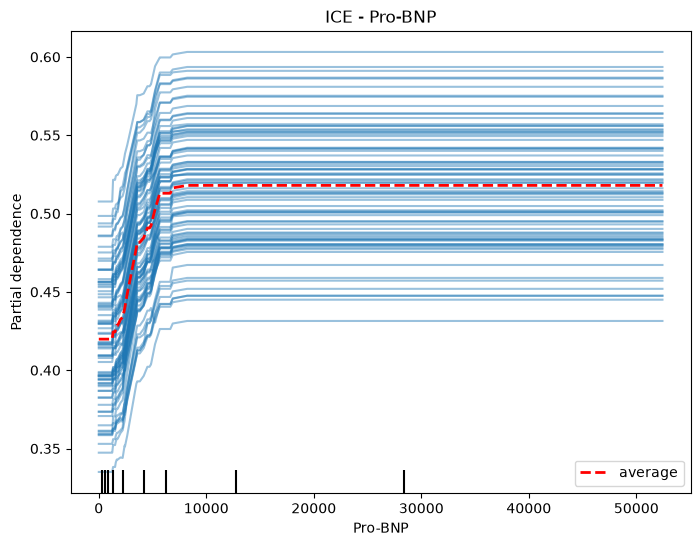

In [36]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
var = "Pro-BNP"

q_low, q_high = X_test[var].quantile([0.01, 0.99])

grid = np.linspace(q_low, q_high, 50)

print("Rango ICE:")
print("1% :", q_low)
print("99%:", q_high)


fig, ax = plt.subplots(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    ice_model,
    X_test,
    features=[var],
    kind="both",
    response_method="predict_proba",
    ax=ax,
    custom_values={var: grid},
        ice_lines_kw={
        "linewidth": 1.5,
        "alpha": 0.45,
    },
    pd_line_kw={
        "linewidth": 2,
        "color": "red"
    },
)
ax.set_title(f"ICE - {var}")
ax.set_ylabel("Probabilidad predicha de desenlace")
plt.show()